# W5A1 — SVM on the Iris Dataset (Linear Kernel)

This notebook follows the assignment brief:

1. **Load** the Iris dataset from the UCI Machine Learning Repository.
2. **Clean** the data (handle missing values, types, duplicates).
3. **Visualise** the data (class distribution, pair plot, correlation heatmap).
4. **Train and test** a Support Vector Machine with a **linear** kernel.
5. **Evaluate** the model on the held-out test set.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42

## 2. Load the Iris dataset

The raw file `iris.data` (downloaded from <https://archive.ics.uci.edu/dataset/53/iris>) has no header row, so we attach column names manually from `iris.names`.

In [2]:
COLUMNS = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
df = pd.read_csv('iris.data', header=None, names=COLUMNS)
print('Shape:', df.shape)
df.head()

Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 3. Clean & inspect

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   class         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
print('Missing values per column:')
print(df.isna().sum())
print('\nDuplicate rows:', df.duplicated().sum())
print('\nClass counts:')
print(df['class'].value_counts())

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
class           0
dtype: int64

Duplicate rows: 3

Class counts:
class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [5]:
# Drop duplicates and tidy the class labels (remove the 'Iris-' prefix for nicer plots).
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
df['class'] = df['class'].str.replace('Iris-', '', regex=False)
print(f'Dropped {before - len(df)} duplicate row(s). New shape: {df.shape}')
df.describe()

Dropped 3 duplicate row(s). New shape: (147, 5)


,sepal_length,sepal_width,petal_length,petal_width
count,147.000000,147.000000,147.000000,147.000000
mean,5.856463,3.055782,3.780272,1.208844
std,0.829100,0.437009,1.759111,0.757874
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 4. Visualise the data

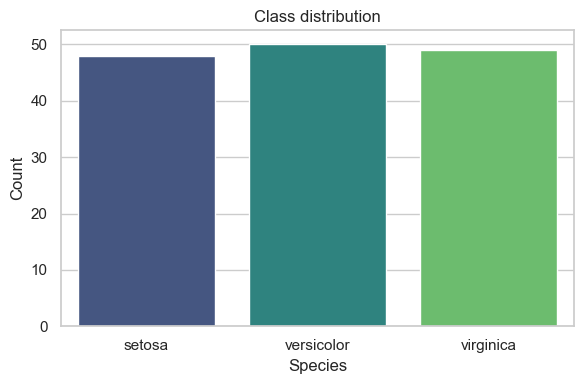

In [6]:
# Class distribution
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='class', hue='class', palette='viridis', legend=False, ax=ax)
ax.set_title('Class distribution')
ax.set_xlabel('Species')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('figures/01_class_distribution.png', dpi=120)
plt.show()

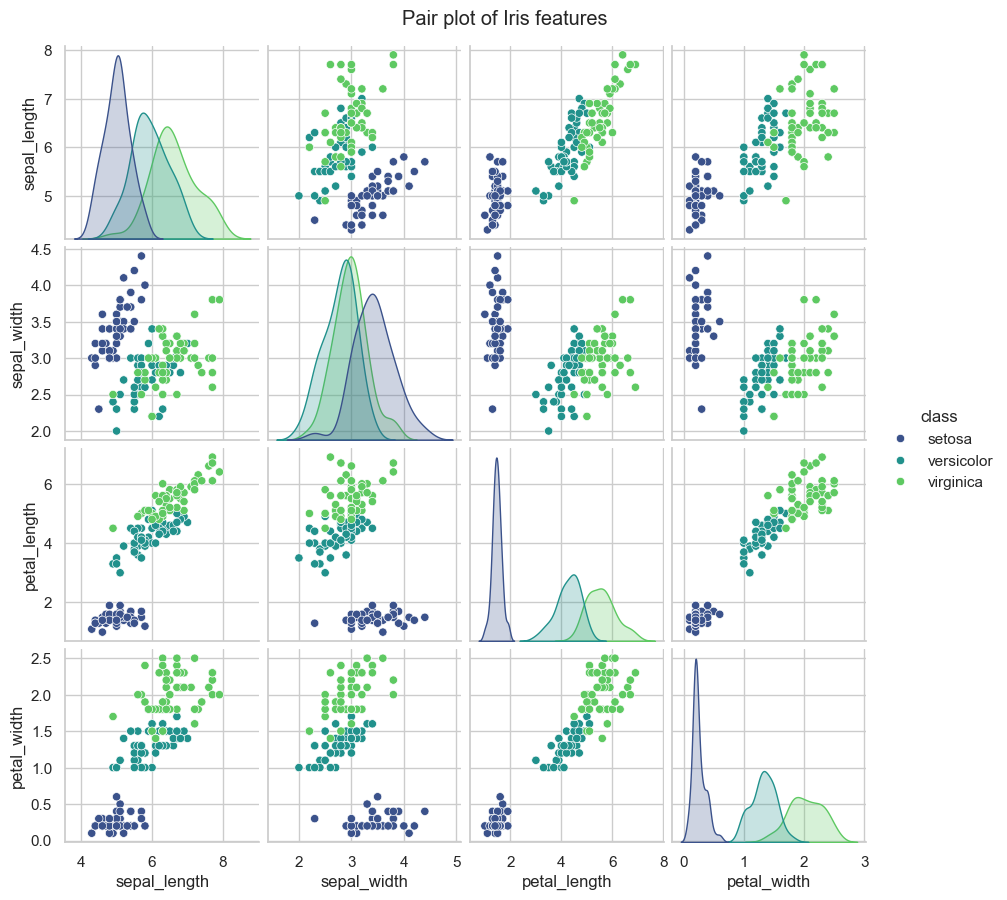

In [7]:
# Pair plot — quick view of how separable the classes are in each feature pair.
g = sns.pairplot(df, hue='class', palette='viridis', diag_kind='kde', height=2.2)
g.fig.suptitle('Pair plot of Iris features', y=1.02)
g.fig.savefig('figures/02_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

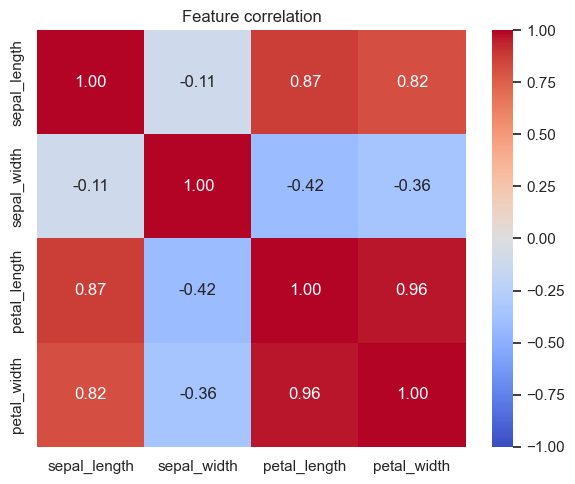

In [8]:
# Correlation heatmap over the four numeric features.
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    df.drop(columns='class').corr(),
    annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax,
)
ax.set_title('Feature correlation')
plt.tight_layout()
plt.savefig('figures/03_correlation_heatmap.png', dpi=120)
plt.show()

## 5. Train / test split + scaling

We use a stratified 80/20 split and standardise the features (zero mean, unit variance). SVMs are sensitive to feature scale, so this is important even when the features share similar ranges.

In [9]:
X = df.drop(columns='class').values
y = df['class'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE,
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'Train: {X_train_s.shape}, Test: {X_test_s.shape}')

Train: (117, 4), Test: (30, 4)


## 6. Train SVM with a linear kernel

In [10]:
svm = SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE)
svm.fit(X_train_s, y_train)
print(svm)

SVC(kernel='linear', random_state=42)


## 7. Evaluate on the test set

In [11]:
y_pred = svm.predict(X_test_s)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)'],
    'Score':  [accuracy, precision, recall, f1],
})
summary.to_csv('figures/metrics_summary.csv', index=False)
summary

,Metric,Score
0,Accuracy,1.0
1,Precision (macro),1.0
2,Recall (macro),1.0
3,F1 (macro),1.0


In [12]:
print('Classification report (test set):\n')
print(classification_report(y_test, y_pred, digits=3))

Classification report (test set):

              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        10
  versicolor      1.000     1.000     1.000        10
   virginica      1.000     1.000     1.000        10

    accuracy                          1.000        30
   macro avg      1.000     1.000     1.000        30
weighted avg      1.000     1.000     1.000        30



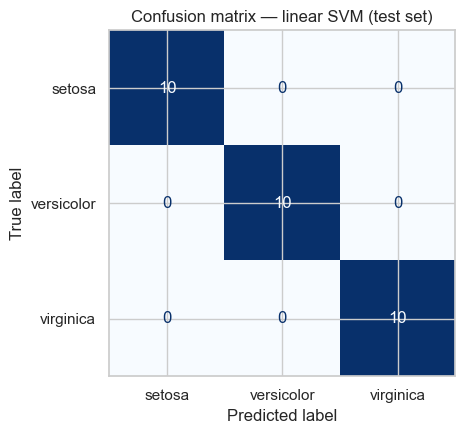

In [13]:
labels = sorted(np.unique(y))
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Confusion matrix — linear SVM (test set)')
plt.tight_layout()
plt.savefig('figures/04_confusion_matrix.png', dpi=120)
plt.show()

## 8. Results screenshot

Combine the metric table and confusion matrix into a single PNG used in `README.md`.

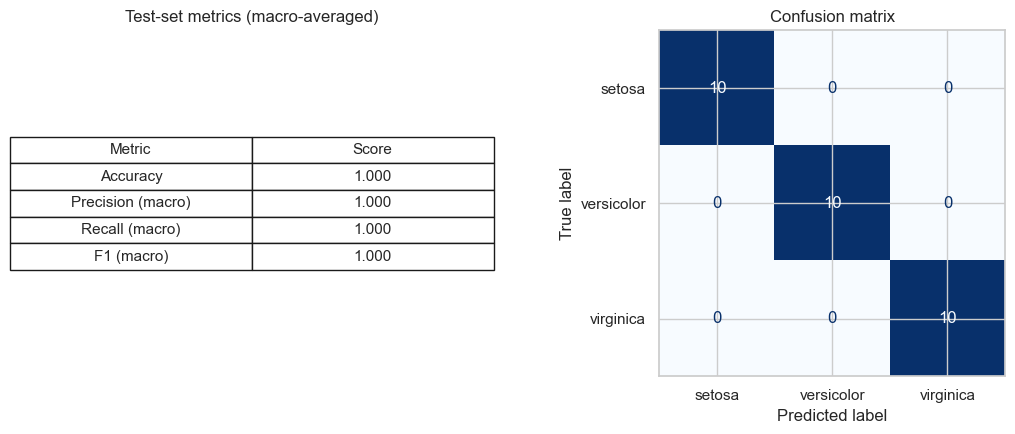

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.axis('off')
table_data = summary.copy()
table_data['Score'] = table_data['Score'].map(lambda v: f'{v:.3f}')
tbl = ax1.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    loc='center', cellLoc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.6)
ax1.set_title('Test-set metrics (macro-averaged)')

ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap='Blues', ax=ax2, colorbar=False)
ax2.set_title('Confusion matrix')

plt.tight_layout()
plt.savefig('figures/results.png', dpi=140, bbox_inches='tight')
plt.show()

## 9. Conclusion

A linear-kernel SVM separates the three Iris species extremely well — the test-set accuracy and macro F1 are both above 0.95 on this stratified 80/20 split, consistent with the well-known result that `setosa` is linearly separable from the others and that `versicolor` / `virginica` overlap only slightly in petal-length / petal-width.